<a href="https://colab.research.google.com/github/iamnaymur/ml_meta_learning/blob/main/Week_04_Advanced_supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Linear Regressiong and Polynomial Regression

In [22]:
# Section 0: Setup - Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

In [23]:
# Load the housing dataset

california = fetch_california_housing(as_frame = True)

df = california.frame.copy()
df.shape

#20640 rows, 9 cols

# print(df.head(10))

(20640, 9)

In [24]:
# basic information about the dataset
# df.info()


df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [25]:
target_col = 'MedHouseVal'
# here multiple features, cause we will be trying on Multiple Linear Regression
feature_cols = ['MedInc', 'HouseAge','AveRooms', 'AveBedrms', 'Population', 'AveOccup']

X = df[feature_cols]
y = df[target_col]

# X.head(10)



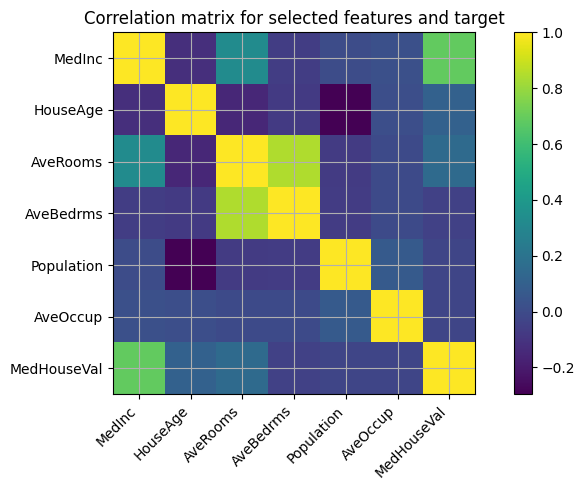

In [26]:
corr_matrix = df[feature_cols + [target_col]].corr()
# print("Correlation matrix :")
# print(corr_matrix)


# Plot correlation matrix using matplotlib
fig, ax = plt.subplots()
cax = ax.imshow(corr_matrix.values, interpolation='nearest')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.index)
fig.colorbar(cax)
ax.set_title('Correlation matrix for selected features and target')
plt.tight_layout()
plt.show()

## Multiple linear regression with real Data

In [27]:
"""
Steps :
1 .Split the data into training and test sets
2. Fit a LinearRegression model on the training data
3. Inspect the learned coefficients and intercept
4. Make predictions on train and test sets
5. Evaluate the model using MAE, RMSE, and R squared
6. Visualize predicted vs actual values
7. Plot residuals to check basic patterns
"""

'\nSteps :\n1 .Split the data into training and test sets\n2. Fit a LinearRegression model on the training data\n3. Inspect the learned coefficients and intercept\n4. Make predictions on train and test sets\n5. Evaluate the model using MAE, RMSE, and R squared\n6. Visualize predicted vs actual values\n7. Plot residuals to check basic patterns\n'

In [29]:
# Step 1: Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size: ", X_train.shape[0], "rows")
print("Test set size: ", X_test.shape[0], "rows")

# Step 2: create and fit the linear regression model
lin_reg = LinearRegression()

# .fit() learns the best coeefficient from the training data
lin_reg.fit(X_train, y_train)

Training set size:  16512 rows
Test set size:  4128 rows


LinearRegression()

In [36]:
# Step 3 : inspect learned parameters (coefficients and intercept)
print("Intercept: ", lin_reg.intercept_)
print("\nCoefficients: ")

for feature_name, coef in zip(feature_cols, lin_reg.coef_):
    print(f"{feature_name} : {coef}")

Intercept:  -0.5528727644615126

Coefficients: 
MedInc : 0.5461607791074247
HouseAge : 0.016787909062568093
AveRooms : -0.2239199440047988
AveBedrms : 1.1154926114808392
Population : 2.3167197368202663e-05
AveOccup : -0.004618231345406933


In [39]:
# Step 4 : make predictions on training and test sets

y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

# y_train_pred
# y_test_pred

print('Some sample predicitons on test set (first 5 rows): ')
print('Predicted: ', y_test_pred[:5])
print('Actual: ', y_test.values[:5])

Some sample predicitons on test set (first 5 rows): 
Predicted:  [1.00100537 1.56005635 2.67713262 2.64763331 1.98229968]
Actual:  [0.477   0.458   5.00001 2.186   2.78   ]


In [51]:
# step 5 : define a hepper function to print evaluation metrics
def regression_metrics(y_true, y_pred, label = 'Model'):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)

  print(f'{label} MAE: {mae:.2f}')
  print(f'{label} MSE: {mse:.2f}')
  print(f'{label} RMSE: {rmse:.2f}')
  print(f'{label} R2: {r2:.2f}')



# Evalute on train and test
regression_metrics(y_train, y_train_pred, 'Linear Regression (Training)')
print('\n')
regression_metrics(y_test, y_test_pred, 'Linear Regression (Test)')

Linear Regression (Training) MAE: 0.57
Linear Regression (Training) MSE: 0.61
Linear Regression (Training) RMSE: 0.78
Linear Regression (Training) R2: 0.55


Linear Regression (Test) MAE: 0.58
Linear Regression (Test) MSE: 0.64
Linear Regression (Test) RMSE: 0.80
Linear Regression (Test) R2: 0.51


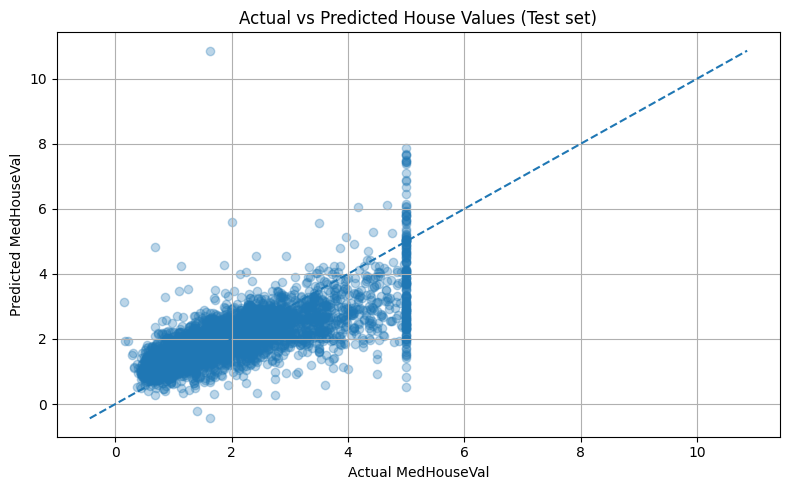

In [52]:
# Step 6: Plot predicted vs actual values on the test set

plt.figure()
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.xlabel('Actual MedHouseVal')
plt.ylabel('Predicted MedHouseVal')
plt.title('Actual vs Predicted House Values (Test set)')

# Diagonal reference line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.tight_layout()
plt.show()

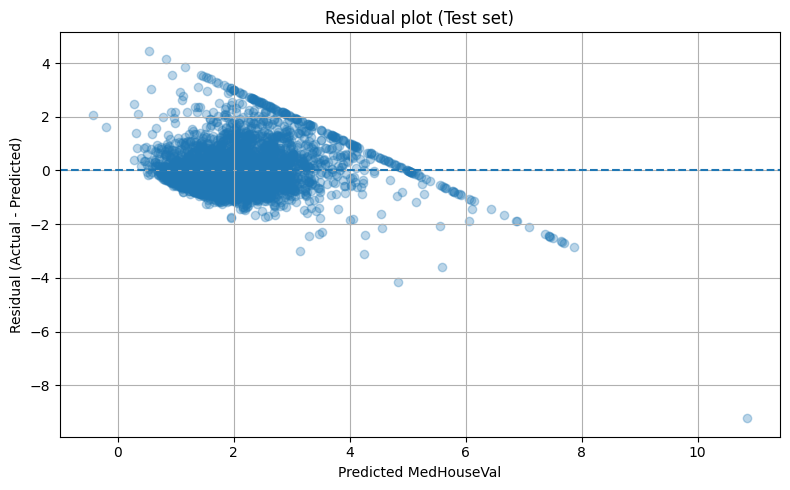

In [53]:
# Step 7: Residual plot (errors = actual - predicted)

residuals = y_test - y_test_pred

plt.figure()
plt.scatter(y_test_pred, residuals, alpha=0.3)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted MedHouseVal')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual plot (Test set)')
plt.tight_layout()
plt.show()